In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

2025-10-25 04:24:54.706581: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-25 04:24:54.758828: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-25 04:24:56.232874: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
filepath = 'dataset/train_FD001.txt'

In [3]:
column_names = [
    'unit_number', 'time_in_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
    'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
    'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18',
    'sensor_19', 'sensor_20', 'sensor_21'
]

In [4]:
df = pd.read_csv(filepath, sep='\s+', header=None, names=column_names)

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_30919/4261351530.py:1: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(filepath, sep='\s+', header=None, names=column_names)


In [5]:
df

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unit_number     20631 non-null  int64  
 1   time_in_cycles  20631 non-null  int64  
 2   op_setting_1    20631 non-null  float64
 3   op_setting_2    20631 non-null  float64
 4   op_setting_3    20631 non-null  float64
 5   sensor_1        20631 non-null  float64
 6   sensor_2        20631 non-null  float64
 7   sensor_3        20631 non-null  float64
 8   sensor_4        20631 non-null  float64
 9   sensor_5        20631 non-null  float64
 10  sensor_6        20631 non-null  float64
 11  sensor_7        20631 non-null  float64
 12  sensor_8        20631 non-null  float64
 13  sensor_9        20631 non-null  float64
 14  sensor_10       20631 non-null  float64
 15  sensor_11       20631 non-null  float64
 16  sensor_12       20631 non-null  float64
 17  sensor_13       20631 non-null 

In [7]:
#the std will be 0 if the sensor is useless
df.describe()

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [8]:
df.isnull().sum()

unit_number       0
time_in_cycles    0
op_setting_1      0
op_setting_2      0
op_setting_3      0
sensor_1          0
sensor_2          0
sensor_3          0
sensor_4          0
sensor_5          0
sensor_6          0
sensor_7          0
sensor_8          0
sensor_9          0
sensor_10         0
sensor_11         0
sensor_12         0
sensor_13         0
sensor_14         0
sensor_15         0
sensor_16         0
sensor_17         0
sensor_18         0
sensor_19         0
sensor_20         0
sensor_21         0
dtype: int64

In [9]:
engine_1_data = df[df['unit_number'] == 1]
engine_1_data

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,1,188,-0.0067,0.0003,100.0,518.67,643.75,1602.38,1422.78,14.62,...,519.79,2388.23,8117.69,8.5207,0.03,396,2388,100.0,38.51,22.9588
188,1,189,-0.0006,0.0002,100.0,518.67,644.18,1596.17,1428.01,14.62,...,519.58,2388.33,8117.51,8.5183,0.03,395,2388,100.0,38.48,23.1127
189,1,190,-0.0027,0.0001,100.0,518.67,643.64,1599.22,1425.95,14.62,...,520.04,2388.35,8112.58,8.5223,0.03,398,2388,100.0,38.49,23.0675
190,1,191,-0.0000,-0.0004,100.0,518.67,643.34,1602.36,1425.77,14.62,...,519.57,2388.30,8114.61,8.5174,0.03,394,2388,100.0,38.45,23.1295


In [10]:
#sensor2, sensor3, sensor4, sensor7, 8,9,11,12,13,14,15,17,20,21   <= selected sensors

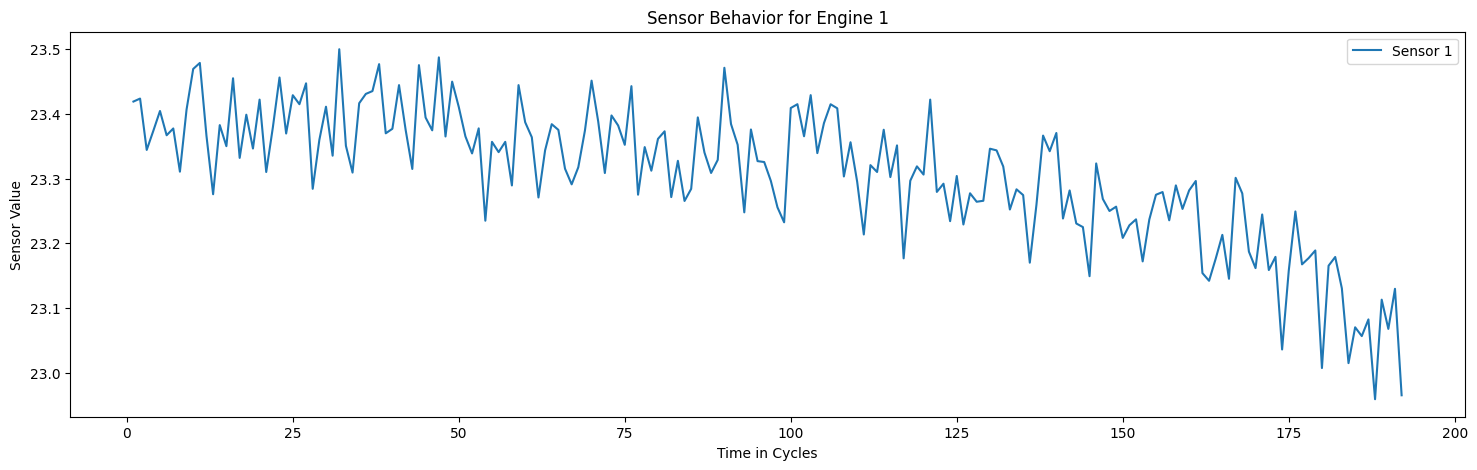

In [11]:
plt.figure(figsize=(18, 5))
plt.plot(engine_1_data['time_in_cycles'], engine_1_data['sensor_21'], label='Sensor 1')

plt.xlabel("Time in Cycles")
plt.ylabel("Sensor Value")
plt.title("Sensor Behavior for Engine 1")
plt.legend()
plt.show()

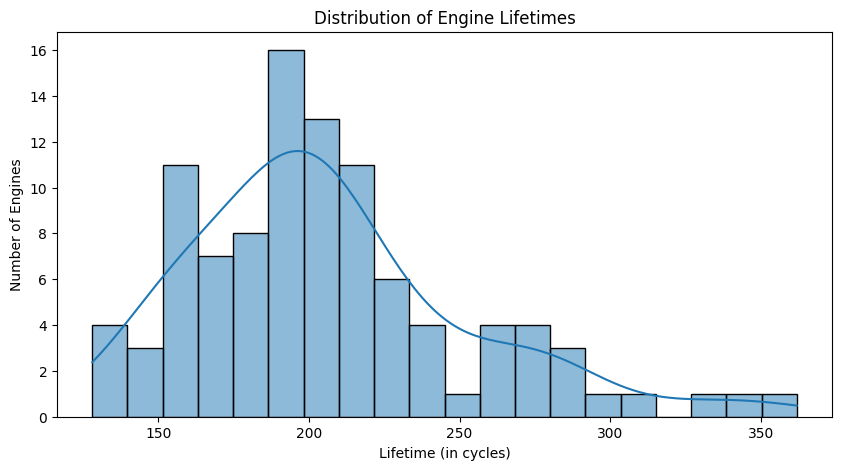

In [12]:
# Find the maximum cycle for each engine
lifetimes = df.groupby('unit_number')['time_in_cycles'].max()

# Plot a histogram of the lifetimes
plt.figure(figsize=(10, 5))
sns.histplot(lifetimes, bins=20, kde=True)
plt.xlabel("Lifetime (in cycles)")
plt.ylabel("Number of Engines")
plt.title("Distribution of Engine Lifetimes")
plt.show()

In [13]:
#normalization of sensor data
useful_sensors = [
    'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9',
    'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17',
    'sensor_20', 'sensor_21'
]
feature_columns = ['op_setting_1', 'op_setting_2', 'op_setting_3'] + useful_sensors

In [14]:
train_df = df[feature_columns]

In [15]:
scaler = MinMaxScaler()

In [16]:
df_normalized = pd.DataFrame(scaler.fit_transform(train_df), columns=train_df.columns)

In [17]:
df.describe()

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [18]:
df_normalized.describe()

,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.0,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000
mean,0.499490,0.501959,0.0,0.443052,0.424746,0.450435,0.566459,0.297957,0.195248,0.411410,0.580697,0.317871,0.226095,0.451118,0.434221,0.524241,0.546127
std,0.125708,0.244218,0.0,0.150618,0.133664,0.151935,0.142527,0.107554,0.099089,0.158981,0.157261,0.105763,0.098442,0.144306,0.129064,0.140114,0.149476
min,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.413793,0.333333,0.0,0.335843,0.331807,0.339467,0.476651,0.227273,0.140761,0.297619,0.484009,0.235294,0.171870,0.346287,0.333333,0.434109,0.452361
50%,0.500000,0.500000,0.0,0.430723,0.415522,0.435348,0.578100,0.287879,0.174684,0.392857,0.594883,0.308824,0.209516,0.438630,0.416667,0.534884,0.557443
75%,0.586207,0.750000,0.0,0.539157,0.508829,0.545324,0.669887,0.363636,0.213991,0.505952,0.695096,0.382353,0.249613,0.541362,0.500000,0.627907,0.652582
max,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [19]:
# First, add the original unit_number and time_in_cycles back to your normalized data
df_normalized['unit_number'] = df['unit_number']
df_normalized['time_in_cycles'] = df['time_in_cycles']

# Calculate the maximum cycle for each engine
max_cycles = df.groupby('unit_number')['time_in_cycles'].max().reset_index()
max_cycles.columns = ['unit_number', 'max_cycles']

# Merge the max_cycles back into the main dataframe
df_merged = pd.merge(df_normalized, max_cycles, on='unit_number')

# Calculate the RUL
df_merged['RUL'] = df_merged['max_cycles'] - df_merged['time_in_cycles']

# Now you have your features (the normalized sensors) and your target (RUL)
rul = df_merged['RUL']
train_features = df_merged.drop(columns=['unit_number', 'time_in_cycles', 'max_cycles', 'RUL'])


In [20]:
train_features.head()


,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
0,0.459770,0.166667,0.0,0.183735,0.406802,0.309757,0.726248,0.242424,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662
1,0.609195,0.250000,0.0,0.283133,0.453019,0.352633,0.628019,0.212121,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014
2,0.252874,0.750000,0.0,0.343373,0.369523,0.370527,0.710145,0.272727,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375
3,0.540230,0.500000,0.0,0.343373,0.256159,0.331195,0.740741,0.318182,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386
4,0.390805,0.333333,0.0,0.349398,0.257467,0.404625,0.668277,0.242424,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502


In [21]:
rul

0        191
1        190
2        189
3        188
4        187
        ... 
20626      4
20627      3
20628      2
20629      1
20630      0
Name: RUL, Length: 20631, dtype: int64

In [22]:
import numpy as np

def create_sequences(features, labels, sequence_length=30):
    X, y = [], []
    # We need to do this for each engine separately
    for unit_num in features['unit_number'].unique():
        unit_features = features[features['unit_number'] == unit_num].drop(columns=['unit_number'])
        unit_labels = labels[features['unit_number'] == unit_num]

        for i in range(len(unit_features) - sequence_length + 1):
            X.append(unit_features.iloc[i:i + sequence_length].values)
            y.append(unit_labels.iloc[i + sequence_length - 1])

    return np.array(X), np.array(y)

# We need unit_number for this function, so let's use the merged dataframe
features_with_unit = df_merged.drop(columns=['time_in_cycles', 'max_cycles', 'RUL'])

# Define sequence length
sequence_length = 30

# Create the sequences
X_train, y_train = create_sequences(features_with_unit, rul, sequence_length)

# Check the shape of your new data
# It should be (number of samples, 30, number of features)
print(f"Shape of X_train: {X_train.shape}")
# It should be (number of samples,)
print(f"Shape of y_train: {y_train.shape}")

Shape of X_train: (17731, 30, 17)
Shape of y_train: (17731,)


In [23]:
n_timesteps = X_train.shape[1]
n_features = X_train.shape[2]

In [24]:
n_timesteps

30

In [25]:
n_features

17

In [26]:
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(n_timesteps, n_features)))
model.add(Dropout(0.2))
model.add(LSTM(units=50))
model.add(Dropout(0.2))
model.add(Dense(units=1))

2025-10-25 04:25:11.161596: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        13,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,851 (132.23 KB)

 Trainable params: 33,851 (132.23 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [28]:
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

print("Model training complete!")

Epoch 1/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 8712.1006 - val_loss: 10976.7705
Epoch 2/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 6140.8154 - val_loss: 8525.9219
Epoch 3/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 4704.3989 - val_loss: 7054.4204
Epoch 4/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 3976.2339 - val_loss: 6216.6743
Epoch 5/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 3640.8508 - val_loss: 5783.7856
Epoch 6/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 3531.4849 - val_loss: 5576.5879
Epoch 7/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 3498.6765 - val_loss: 5494.8643
Epoch 8/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 3494.1528 - val_loss: 5453.7856
Epoch 9/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 3481.7659 - val_loss: 5441.3926
Epoch 10/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 3500.8765 - val_loss: 5439.1523
Epoch 11/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 3486.0

In [30]:
test_df = pd.read_csv('dataset/test_FD001.txt', sep='\s+', header=None, names=column_names)
true_rul = pd.read_csv('dataset/RUL_FD001.txt', header=None)

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_30919/1689744761.py:1: SyntaxWarning: invalid escape sequence '\s'
  test_df = pd.read_csv('dataset/test_FD001.txt', sep='\s+', header=None, names=column_names)


In [31]:
feature_columns = ['op_setting_1', 'op_setting_2', 'op_setting_3'] + useful_sensors
test_features = test_df[feature_columns]

In [32]:
test_normalized = pd.DataFrame(scaler.transform(test_features), columns=feature_columns)

In [33]:
sequence_length = 30
X_test = []
for unit_num in test_df['unit_number'].unique():
    unit_data = test_normalized[test_df['unit_number'] == unit_num]
    # Take the last 'sequence_length' cycles for each engine
    X_test.append(unit_data.iloc[-sequence_length:].values)

X_test = np.array(X_test)
y_test = true_rul.values.flatten()

print(f"Shape of X_test: {X_test.shape}")

Shape of X_test: (100, 30, 17)


In [34]:
y_pred = model.predict(X_test).flatten()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


In [35]:
from sklearn.metrics import mean_squared_error

# Calculate the RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Square Error (RMSE) on Test Data: {rmse}")

Root Mean Square Error (RMSE) on Test Data: 18.988342724519907


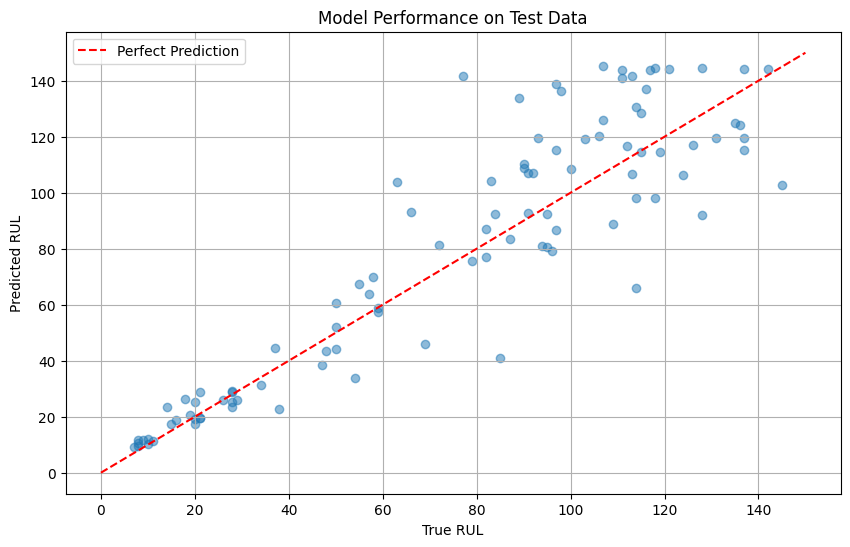

In [36]:
import matplotlib.pyplot as plt

# Plot true RUL vs. predicted RUL
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([0, 150], [0, 150], 'r--', label='Perfect Prediction') # A line for reference
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Model Performance on Test Data")
plt.legend()
plt.grid(True)
plt.show()

In [37]:
#fedavg

In [38]:
client_data = []

In [39]:
features_with_unit = df_merged.drop(columns=['time_in_cycles', 'max_cycles', 'RUL'])
rul = df_merged['RUL']
sequence_length = 30

In [42]:
for unit_num in df_merged['unit_number'].unique():
    # Get all data for the current engine
    unit_features_df = features_with_unit[features_with_unit['unit_number'] == unit_num]
    unit_rul_df = rul[features_with_unit['unit_number'] == unit_num]

    # Drop the unit_number column now that we've filtered
    unit_features_df = unit_features_df.drop(columns=['unit_number'])

    # Create sequences for this single engine
    X_client, y_client = [], []
    for i in range(len(unit_features_df) - sequence_length + 1):
        X_client.append(unit_features_df.iloc[i:i + sequence_length].values)
        y_client.append(unit_rul_df.iloc[i + sequence_length - 1])

    if len(X_client) > 0:
        client_data.append((np.array(X_client), np.array(y_client)))

# Now you have a list of 100 tuples, each containing the (X, y) data for one engine.
print(f"Number of clients (engines): {len(client_data)}")
print(f"Shape of data for the first client: {client_data[0][0].shape}, {client_data[0][1].shape}")

Number of clients (engines): 300
Shape of data for the first client: (163, 30, 17), (163,)


In [43]:
from tensorflow.keras.models import clone_model

# Function to build a fresh, compiled model
def build_model():
    model = Sequential()
    model.add(LSTM(units=50, return_sequences=True, input_shape=(n_timesteps, n_features)))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50))
    model.add(Dropout(0.2))
    model.add(Dense(units=1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Initialize the global model
global_model = build_model()

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [48]:
import numpy as np

# --- Hyperparameters for Federated Learning ---
COMMUNICATION_ROUNDS = 50
LOCAL_EPOCHS = 5 # Number of times each client trains on its data per round
NUM_CLIENTS = len(client_data)
local_model = build_model()
# --- Main Training Loop ---
for comm_round in range(COMMUNICATION_ROUNDS):
    print(f"--- Communication Round {comm_round + 1}/{COMMUNICATION_ROUNDS} ---")

    # Get the current weights of the global model
    global_weights = global_model.get_weights()
    
    # A list to hold all the model updates from clients
    local_weight_updates = []

    # --- Simulate Client Training ---
    for client_id in range(NUM_CLIENTS):
        # Create a local model
        #local_model = build_model()
        # Set its weights to be the same as the global model
        local_model.set_weights(global_weights)
        
        # Get the client's data
        X_client, y_client = client_data[client_id]
        
        # Train the local model on its own data
        local_model.fit(X_client, y_client, epochs=LOCAL_EPOCHS, verbose=0, batch_size=32)
        
        # Get the updated weights and add them to our list
        local_weight_updates.append(local_model.get_weights())

    # --- Federated Averaging (Server-side) ---
    # Calculate the average of all the local weight updates 
    average_weights = list()
    for weights_list_tuple in zip(*local_weight_updates):
        layer_mean = np.mean(np.array(weights_list_tuple), axis=0)
        average_weights.append(layer_mean)
    
    # Update the global model with the new, averaged weights
    global_model.set_weights(average_weights)

print("Federated training complete!")

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


--- Communication Round 1/50 ---
--- Communication Round 2/50 ---
--- Communication Round 3/50 ---
--- Communication Round 4/50 ---
--- Communication Round 5/50 ---
--- Communication Round 6/50 ---
--- Communication Round 7/50 ---
--- Communication Round 8/50 ---
--- Communication Round 9/50 ---
--- Communication Round 10/50 ---
--- Communication Round 11/50 ---
--- Communication Round 12/50 ---
--- Communication Round 13/50 ---
--- Communication Round 14/50 ---
--- Communication Round 15/50 ---
--- Communication Round 16/50 ---
--- Communication Round 17/50 ---
--- Communication Round 18/50 ---
--- Communication Round 19/50 ---
--- Communication Round 20/50 ---
--- Communication Round 21/50 ---
--- Communication Round 22/50 ---
--- Communication Round 23/50 ---
--- Communication Round 24/50 ---
--- Communication Round 25/50 ---
--- Communication Round 26/50 ---
--- Communication Round 27/50 ---
--- Communication Round 28/50 ---
--- Communication Round 29/50 ---
--- Communication Round

In [49]:
y_pred_fl = global_model.predict(X_test).flatten()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [50]:
rmse_fl = np.sqrt(mean_squared_error(y_test, y_pred_fl))

# Print both scores for a direct comparison
print(f"Centralized Baseline RMSE: {rmse}") # The variable from your first evaluation
print(f"Federated Model RMSE:      {rmse_fl}")

Centralized Baseline RMSE: 18.988342724519907
Federated Model RMSE:      41.56989184738306
